In [1]:
# --- Parameter Heatmaps (refined + frontier) ---
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

sns.set(style="whitegrid", context="talk")

df = pd.read_csv("../experiments/results_sweep_refined/sweep_refined_mean_std.csv")
frontier = pd.read_csv("../experiments/results_sweep_refined/frontier_curve.csv")

def heatmap(df, value_col, title, fmt=".2f", cmap="viridis"):
    piv = df.pivot(index="epsilon", columns="p_cut", values=value_col)
    plt.figure(figsize=(9,6))
    ax = sns.heatmap(piv, annot=False, cmap=cmap)
    plt.title(title)
    plt.xlabel("p_cut")
    plt.ylabel("epsilon")

    # superponer frontera: interpolar la curva sobre el eje
    f = frontier.dropna()
    if not f.empty:
        xs = f["p_cut_star"].values
        ys = f["epsilon"].values
        # mapear a coordenadas del heatmap
        # (aprox: usamos valores reales sobre el mismo eje)
        plt.plot(xs, ys, marker="o", lw=2, color="red", label="Frontera (frac_largest<0.95)")
        plt.legend()
    plt.tight_layout()
    plt.show()

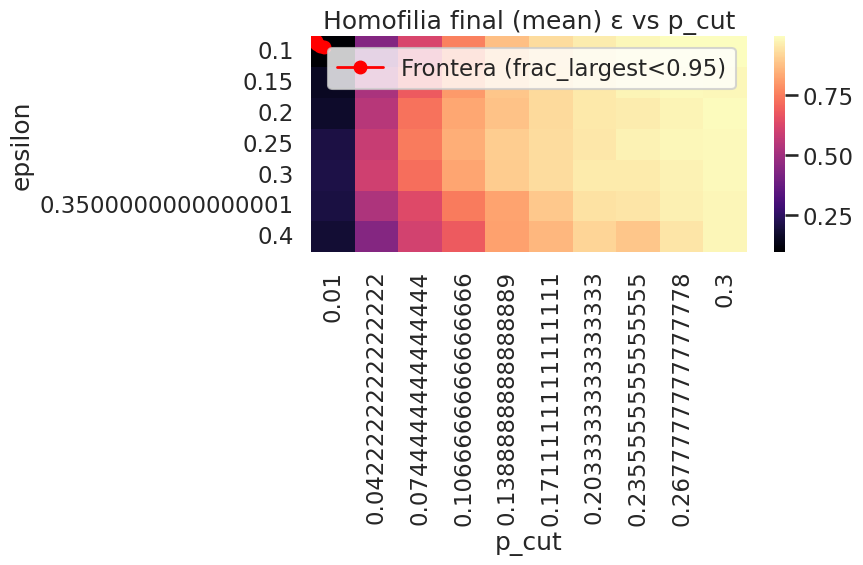

In [2]:

# Promedio Homofilia (mean)
heatmap(df, "homophily_mean", "Homofilia final (mean) ε vs p_cut", cmap="magma")

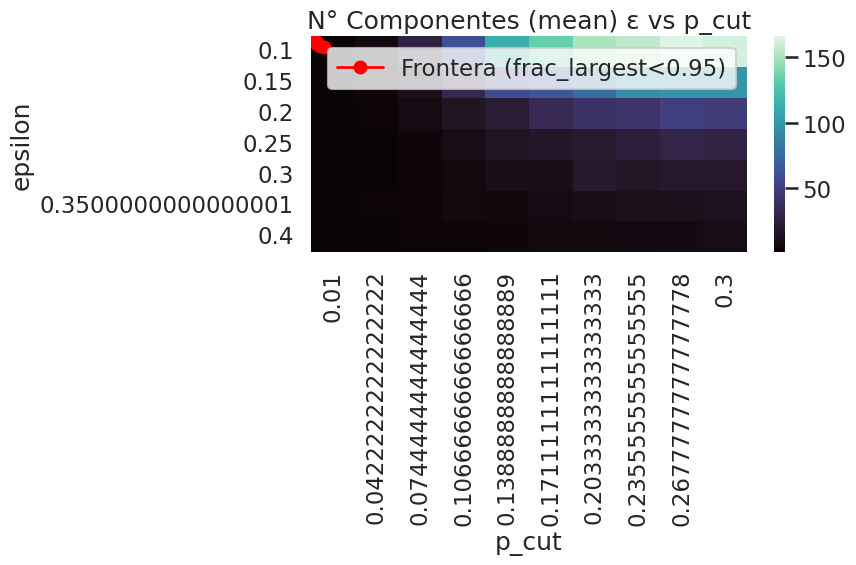

In [3]:
# Promedio n_components (mean)
heatmap(df, "n_components_mean", "N° Componentes (mean) ε vs p_cut", cmap="mako")

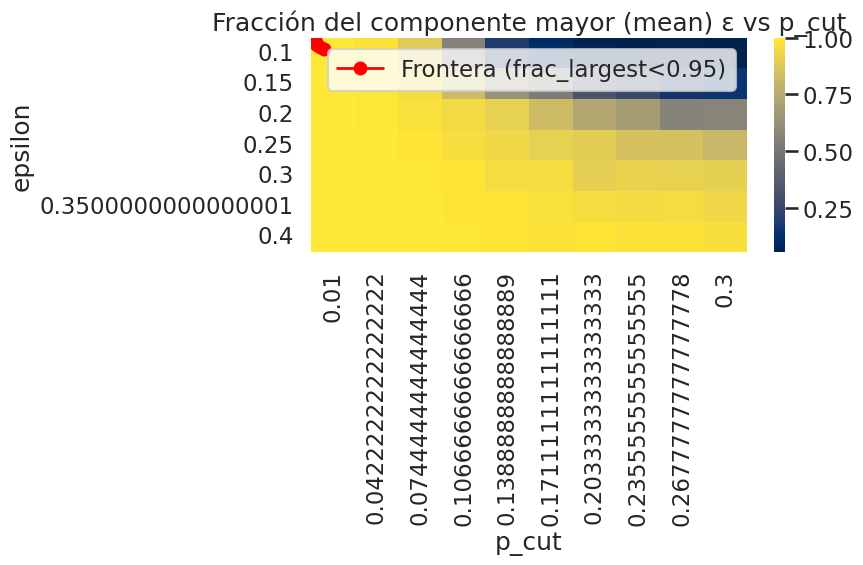

In [4]:
# Promedio frac_largest (mean) con frontera
heatmap(df, "frac_largest_mean", "Fracción del componente mayor (mean) ε vs p_cut", cmap="cividis")

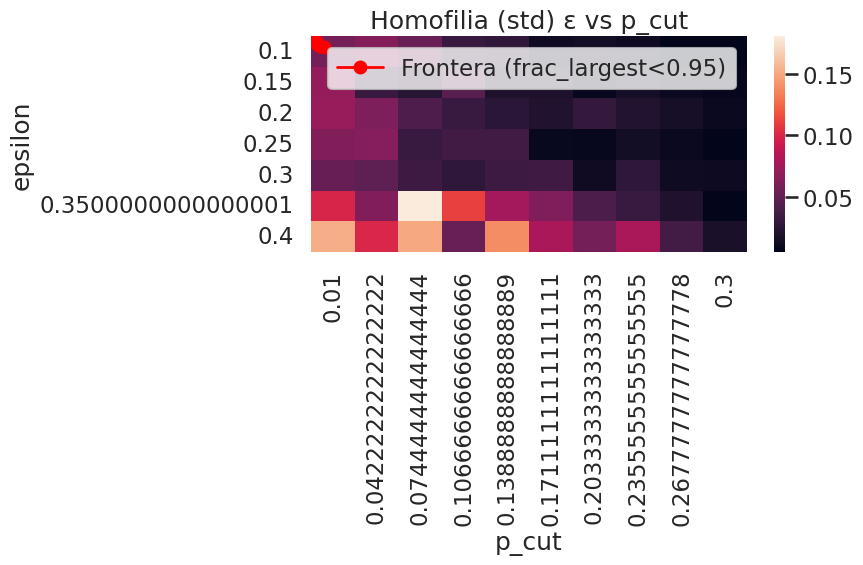

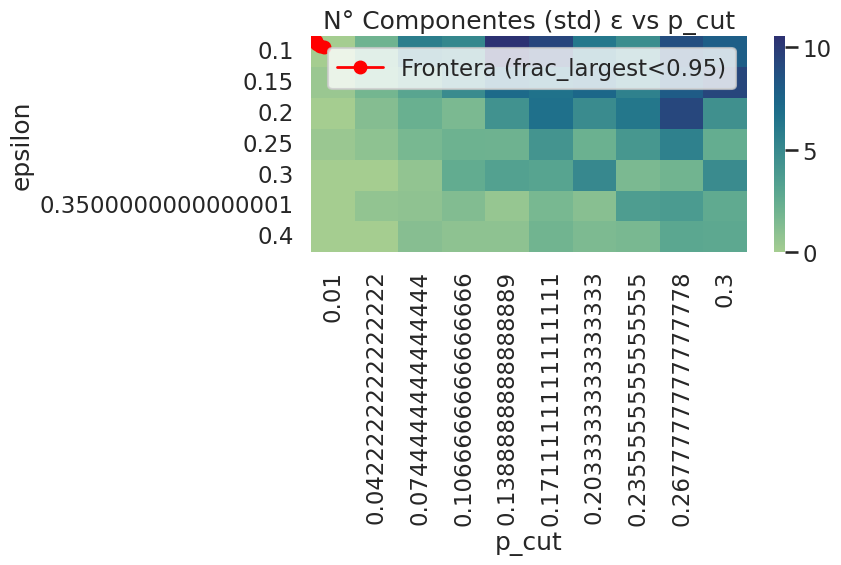

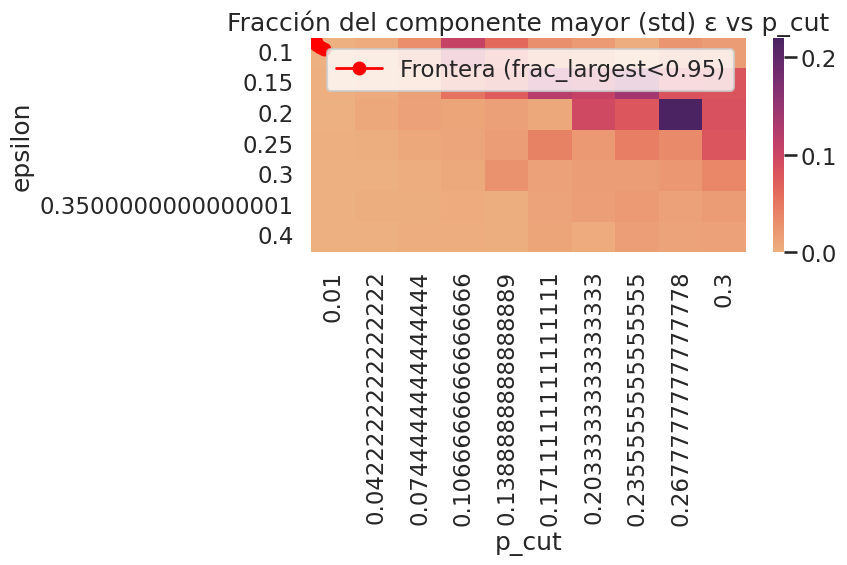

In [5]:
# Mapas de std para ver estabilidad por seeds
heatmap(df, "homophily_std", "Homofilia (std) ε vs p_cut", cmap="rocket")
heatmap(df, "n_components_std", "N° Componentes (std) ε vs p_cut", cmap="crest")
heatmap(df, "frac_largest_std", "Fracción del componente mayor (std) ε vs p_cut", cmap="flare")

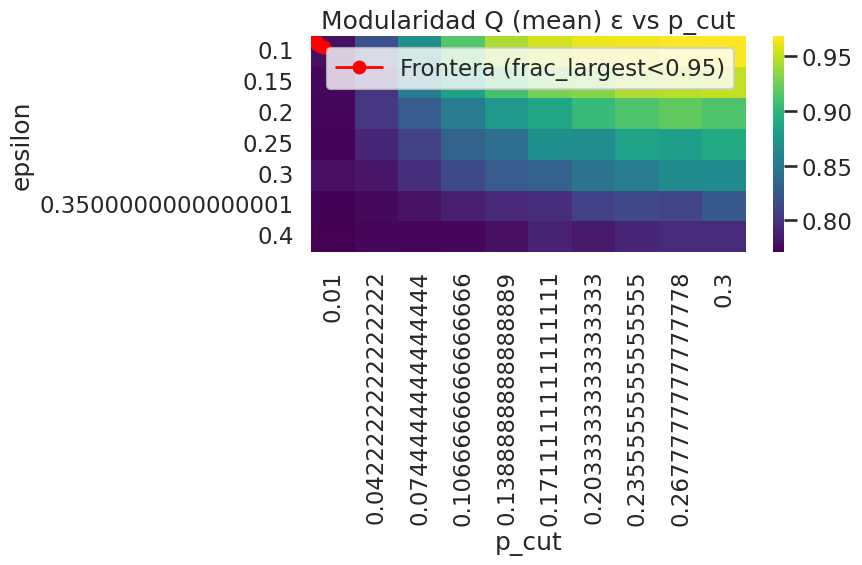

In [6]:
# Modularidad Q (mean)
heatmap(df, "modularity_Q_mean", "Modularidad Q (mean) ε vs p_cut", cmap="viridis")